In [ ]:
import os
import random
import numpy as np
from sklearn.model_selection import train_test_split

SEED = 42
random.seed(SEED)
np.random.seed(SEED)


DATASET_ROOT = r"C:\Users\ASUS\Desktop\project\archive\FaceForensics++_C23"

REAL_DIR = os.path.join(DATASET_ROOT, "original")
FAKE_DIRS = ["Deepfakes", "Face2Face", "FaceSwap", "FaceShifter", "NeuralTextures"]

def collect_videos(limit_per_class=800):
    video_paths = []
    labels = []


    if not os.path.exists(DATASET_ROOT):
        print(f"ERROR: Dataset root not found at {DATASET_ROOT}")
        return [], []

    if os.path.exists(REAL_DIR):
        real_videos = sorted([f for f in os.listdir(REAL_DIR) if f.endswith(".mp4")])
        selected_real = real_videos[:limit_per_class]
        for vid in selected_real:
            video_paths.append(os.path.join(REAL_DIR, vid))
            labels.append(0)
    else:
        print(f"Warning: Real directory not found at {REAL_DIR}")

  
    limit_per_fake_type = limit_per_class // len(FAKE_DIRS)
    
    for fake_type in FAKE_DIRS:
        fake_dir = os.path.join(DATASET_ROOT, fake_type)
        if os.path.exists(fake_dir):
            fake_videos = sorted([f for f in os.listdir(fake_dir) if f.endswith(".mp4")])
            selected_fake = fake_videos[:limit_per_fake_type]
            for vid in selected_fake:
                video_paths.append(os.path.join(fake_dir, vid))
                labels.append(1)
        else:
            print(f"Warning: Folder {fake_type} not found.")

    return video_paths, labels


video_paths, labels = collect_videos(limit_per_class=800)

if len(video_paths) > 0:
    train_paths, val_paths, train_labels, val_labels = train_test_split(
        video_paths, labels, test_size=0.2, stratify=labels, random_state=SEED
    )
    
    print("===================================================")
    print(f"Total videos found: {len(video_paths)}")
    print(f"Real: {labels.count(0)} | Fake: {labels.count(1)}")
    print(f"Train set: {len(train_paths)} | Val set: {len(val_paths)}")
    print("===================================================")
else:
    print("No videos found. Please check your folder paths!")

Total videos found: 1600
Real: 800 | Fake: 800
Train set: 1280 | Val set: 320


In [3]:
import os
import cv2
import torch
import random
import numpy as np
from tqdm import tqdm
from facenet_pytorch import MTCNN
from torchvision import transforms

c:\Users\ASUS\Desktop\project\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import os
import cv2
import torch
import random
import numpy as np
from tqdm import tqdm
from facenet_pytorch import MTCNN
from torchvision import transforms

# =========================
# CONFIG
# =========================
FFPP_ROOT = r"C:\Users\ASUS\Desktop\project\archive\FaceForensics++_C23"
OUT_ROOT  = r"C:\Users\ASUS\Desktop\project\video_fpp"


REAL_DIR = os.path.join(FFPP_ROOT, "original")
FAKE_DIRS = [
    "DeepFakeDetection",
]

MAX_VIDEOS_PER_CLASS = 1000
FRAMES   = 16
IMG_SIZE = 224
DEVICE   = "cuda" if torch.cuda.is_available() else "cpu"

os.makedirs(f"{OUT_ROOT}/real", exist_ok=True)
os.makedirs(f"{OUT_ROOT}/fake", exist_ok=True)

# =========================
# FACE DETECTOR
# =========================
mtcnn = MTCNN(
    image_size=IMG_SIZE,
    margin=20,
    keep_all=False,
    device=DEVICE
)

# =========================
# UNIFORM FRAME SAMPLING
# =========================
def sample_frames(video_path, num_frames=16):
    cap = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total <= 0:
        cap.release()
        return None

    idxs = np.linspace(0, total - 1, num_frames).astype(int)
    frames = []

    for idx in idxs:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if not ret:
            continue
        frames.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

    cap.release()
    return frames if len(frames) == num_frames else None

# =========================
# VIDEO PROCESSING
# =========================
def process_video(video_path):
    frames = sample_frames(video_path, FRAMES)
    if frames is None:
        return None

    faces = []
    for frame in frames:
        face = mtcnn(frame)
        if face is None:
            return None
        faces.append(face)

    return torch.stack(faces)  # (16,3,224,224)

# =========================
# PROCESS REAL VIDEOS
# =========================
print("🔵 Processing REAL videos")

real_videos = sorted(os.listdir(REAL_DIR))
random.shuffle(real_videos)

real_count = 0
for vid in tqdm(real_videos):
    if real_count >= MAX_VIDEOS_PER_CLASS:
        break
    if not vid.endswith(".mp4"):
        continue

    out_path = f"{OUT_ROOT}/real/{real_count:04d}.pt"
    if os.path.exists(out_path):
        real_count += 1
        continue

    tensor = process_video(os.path.join(REAL_DIR, vid))
    if tensor is not None:
        torch.save(tensor.cpu(), out_path)
        real_count += 1

print(f"✅ REAL videos saved: {real_count}")

# =========================
# PROCESS FAKE VIDEOS
# =========================
print("🔴 Processing FAKE videos")

fake_count = 0
for fake_dir in FAKE_DIRS:
    path = os.path.join(FFPP_ROOT, fake_dir)
    if not os.path.exists(path):
        continue

    videos = sorted(os.listdir(path))
    random.shuffle(videos)

    for vid in tqdm(videos):
        if fake_count >= MAX_VIDEOS_PER_CLASS:
            break
        if not vid.endswith(".mp4"):
            continue

        out_path = f"{OUT_ROOT}/fake/{fake_count:04d}.pt"
        if os.path.exists(out_path):
            fake_count += 1
            continue

        tensor = process_video(os.path.join(path, vid))
        if tensor is not None:
            torch.save(tensor.cpu(), out_path)
            fake_count += 1

print(f"✅ FAKE videos saved: {fake_count}")


c:\Users\ASUS\Desktop\project\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


🔵 Processing REAL videos


100%|██████████| 1000/1000 [50:14<00:00,  3.01s/it] 


✅ REAL videos saved: 999
🔴 Processing FAKE videos


100%|██████████| 1000/1000 [1:08:49<00:00,  4.13s/it]

✅ FAKE videos saved: 939


In [3]:
import torch

# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {device}")

if device.type == 'cuda':
    print(f"Device Name: {torch.cuda.get_device_name(0)}")
    print(f"Total VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

Using device: cuda
Device Name: NVIDIA GeForce RTX 3050 4GB Laptop GPU
Total VRAM: 4.29 GB


In [1]:
import os
import random
import numpy as np
from glob import glob
from tqdm import tqdm
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score

# =========================================================
# CONFIGURATION
# =========================================================
SEED = 42
BATCH_SIZE = 2  # Reduced to prevent OOM and speed up start
EPOCHS = 10
LR = 1e-4
FRAMES = 16
PATIENCE = 3

DATA_ROOT = r"C:\Users\ASUS\Desktop\project\video_fpp"
REAL_DIR = os.path.join(DATA_ROOT, "real")
FAKE_DIR = os.path.join(DATA_ROOT, "fake")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# =========================================================
# GPU OPTIMIZATION
# =========================================================
torch.backends.cudnn.benchmark = True
torch.backends.cudnn.deterministic = False

# =========================================================
# REPRODUCIBILITY
# =========================================================
def seed_everything(seed):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(SEED)

# =========================================================
# DATASET
# =========================================================
class VideoDataset(Dataset):
    def __init__(self, files, labels, augment=False):
        self.files = files
        self.labels = labels
        self.augment = augment

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        x = torch.load(self.files[idx]) # Shape: [T, C, H, W]
        y = self.labels[idx]

        if self.augment:
            if random.random() < 0.5:
                x = torch.flip(x, [-1])
            if random.random() < 0.2:
                x = x + (torch.randn_like(x) * 0.01)

        return x, y

# =========================================================
# LOAD DATA
# =========================================================
real_files = sorted(glob(os.path.join(REAL_DIR, "*.pt")))
fake_files = sorted(glob(os.path.join(FAKE_DIR, "*.pt")))
files = real_files + fake_files
labels = [0]*len(real_files) + [1]*len(fake_files)

X_train, X_val, y_train, y_val = train_test_split(
    files, labels, test_size=0.2, stratify=labels, random_state=SEED
)

class_counts = np.bincount(y_train)
sample_weights = [1.0/class_counts[y] for y in y_train]
sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

# Set num_workers=0 for Windows to avoid the 0% hang issue
train_loader = DataLoader(
    VideoDataset(X_train, y_train, augment=True),
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    VideoDataset(X_val, y_val, augment=False),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

# =========================================================
# MODEL
# =========================================================
class EfficientNet_BiLSTM(nn.Module):
    def __init__(self):
        super().__init__()
        weights = models.EfficientNet_B0_Weights.IMAGENET1K_V1
        backbone = models.efficientnet_b0(weights=weights)
        self.cnn = backbone.features
        self.pool = nn.AdaptiveAvgPool2d(1)

        self.lstm = nn.LSTM(
            input_size=1280,
            hidden_size=256,
            num_layers=2,
            bidirectional=True,
            batch_first=True,
            dropout=0.3
        )

        self.classifier = nn.Sequential(
            nn.Linear(512, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        B, T, C, H, W = x.shape
        x = x.view(B*T, C, H, W)

        feats = self.cnn(x)
        feats = self.pool(feats).flatten(1)
        feats = feats.view(B, T, -1)

        lstm_out, _ = self.lstm(feats)
        out = lstm_out[:, -1, :] # Last time step

        return self.classifier(out)

model = EfficientNet_BiLSTM().to(DEVICE)

# =========================================================
# OPTIMIZER & AMP
# =========================================================
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=5)
criterion = nn.CrossEntropyLoss()
scaler = torch.amp.GradScaler('cuda')

# =========================================================
# TRAINING
# =========================================================
best_auc = 0.0
counter = 0

print(f"🚀 Training on {DEVICE.upper()}")

for epoch in range(EPOCHS):
    model.train()
    train_preds, train_labels = [], []

    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")
    for x, y in loop:
        x = x.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)

        optimizer.zero_grad()

        with torch.amp.autocast('cuda'):
            out = model(x)
            loss = criterion(out, y)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_preds.extend(out.argmax(1).cpu().numpy())
        train_labels.extend(y.cpu().numpy())
        loop.set_postfix(loss=loss.item())

    scheduler.step()
    train_acc = accuracy_score(train_labels, train_preds)

    model.eval()
    val_probs, val_labels = [], []
    with torch.no_grad():
        for x, y in val_loader:
            x = x.to(DEVICE, non_blocking=True)
            y = y.to(DEVICE, non_blocking=True)

            with torch.amp.autocast('cuda'):
                out = model(x)

            val_probs.extend(torch.softmax(out, 1)[:,1].cpu().numpy())
            val_labels.extend(y.cpu().numpy())

    val_auc = roc_auc_score(val_labels, val_probs)
    print(f"\n✅ Epoch {epoch+1} | Train Acc: {train_acc:.4f} | Val AUC: {val_auc:.4f}")

    # Save model
    torch.save(model.state_dict(), f"efficientnet_epoch{epoch+1}.pt")

    if val_auc > best_auc:
        best_auc = val_auc
        counter = 0
        torch.save(model.state_dict(), "best_model.pt")
        print("⭐ New Best AUC! Model saved as best_model.pt")
    else:
        counter += 1
        if counter >= PATIENCE:
            print(f"🛑 Early stopping triggered after {epoch+1} epochs.")
            break

print(f"\n✨ Training Complete! Best Val AUC: {best_auc:.4f}")

🚀 Training on CUDA


Epoch 1/10: 100%|██████████| 775/775 [03:07<00:00,  4.13it/s, loss=0.121] 



✅ Epoch 1 | Train Acc: 0.7458 | Val AUC: 0.9928
⭐ New Best AUC! Model saved as best_model.pt


Epoch 2/10: 100%|██████████| 775/775 [03:07<00:00,  4.13it/s, loss=1.12]  



✅ Epoch 2 | Train Acc: 0.7600 | Val AUC: 0.9959
⭐ New Best AUC! Model saved as best_model.pt


...


✅ Epoch 4 | Train Acc: 0.7490 | Val AUC: 0.9988


Epoch 5/10: 100%|██████████| 775/775 [03:23<00:00,  3.80it/s, loss=1.2]   



✅ Epoch 5 | Train Acc: 0.7735 | Val AUC: 0.9978


Epoch 6/10: 100%|██████████| 775/775 [02:57<00:00,  4.37it/s, loss=0.101] 



✅ Epoch 6 | Train Acc: 0.7400 | Val AUC: 0.9971
🛑 Early stopping triggered after 6 epochs.

✨ Training Complete! Best Val AUC: 0.9988


In [3]:
import torch
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

def evaluate_and_print_results(model, val_loader, device):
    model.eval()
    all_preds = []
    all_labels = []

    print("📊 Generating predictions for Validation Set...")
    with torch.no_grad():
        for x, y in val_loader:
            x = x.to(device)
            # Match the AMP training setup for consistency
            with torch.amp.autocast('cuda'):
                out = model(x)
            
            preds = torch.argmax(out, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())

    # 1. Calculate Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    
    # 2. Manual Text-Based Matrix Formatting
    print("\n" + "="*30)
    print("      CONFUSION MATRIX")
    print("="*30)
    print(f"{'':>15} | {'Pred Real':>10} | {'Pred Fake':>10}")
    print("-" * 43)
    print(f"{'Actual Real':>15} | {cm[0][0]:>10} | {cm[0][1]:>10}")
    print(f"{'Actual Fake':>15} | {cm[1][0]:>10} | {cm[1][1]:>10}")
    print("="*30)

    # 3. Detailed Statistics
    # This gives you Precision, Recall, and F1-score for each class
    print("\n📝 CLASSIFICATION REPORT:")
    print(classification_report(all_labels, all_preds, target_names=['Real', 'Fake']))

# --- EXECUTION ---
# Ensure your model is loaded with 'best_model.pt' before running
evaluate_and_print_results(model, val_loader, DEVICE)

📊 Generating predictions for Validation Set...

      CONFUSION MATRIX
                |  Pred Real |  Pred Fake
-------------------------------------------
    Actual Real |        191 |          9
    Actual Fake |          0 |        188

📝 CLASSIFICATION REPORT:
              precision    recall  f1-score   support

        Real       1.00      0.95      0.98       200
        Fake       0.95      1.00      0.98       188

    accuracy                           0.98       388
   macro avg       0.98      0.98      0.98       388
weighted avg       0.98      0.98      0.98       388



In [4]:
# =========================================================
# FINAL MODEL TESTING SCRIPT (VIDEO DEEPFAKE)
# CNN + BiLSTM | IEEE-READY
# =========================================================
import os
import numpy as np
from glob import glob
from tqdm import tqdm
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

# -------------------------------
# CONFIG
# -------------------------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 4  # Optimized for inference
FRAMES = 16

# Corrected Local Windows Paths
MODEL_PATH = "best_model.pt" 
DATA_ROOT = r"C:\Users\ASUS\Desktop\project\video_fpp"
REAL_DIR = os.path.join(DATA_ROOT, "real")
FAKE_DIR = os.path.join(DATA_ROOT, "fake")

# =========================================================
# DATASET
# =========================================================
class VideoDataset(Dataset):
    def __init__(self, files, labels):
        self.files = files
        self.labels = labels

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        # Assumes pre-processed .pt files (T, C, H, W)
        x = torch.load(self.files[idx])   
        y = self.labels[idx]
        return x, y

# =========================================================
# LOAD TEST FILES
# =========================================================
real_files = sorted(glob(os.path.join(REAL_DIR, "*.pt")))
fake_files = sorted(glob(os.path.join(FAKE_DIR, "*.pt")))

if len(real_files) == 0 or len(fake_files) == 0:
    raise FileNotFoundError(f"❌ Test data not found at {DATA_ROOT}")

test_files = real_files + fake_files
test_labels = [0]*len(real_files) + [1]*len(fake_files)

print("="*35)
print(f"DEVICE: {DEVICE.upper()}")
print(f"Total Test Samples: {len(test_files)}")
print(f"Real : {len(real_files)} | Fake : {len(fake_files)}")
print("="*35)

test_ds = VideoDataset(test_files, test_labels)
test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,  # Set to 0 for Windows stability
    pin_memory=True
)

# =========================================================
# MODEL DEFINITION
# =========================================================
class CNN_BiLSTM(nn.Module):
    def __init__(self):
        super().__init__()
        # Backbone matches training (EfficientNet-B0)
        backbone = models.efficientnet_b0(weights=None)
        self.cnn = backbone.features
        self.pool = nn.AdaptiveAvgPool2d(1)

        self.lstm = nn.LSTM(
            input_size=1280,
            hidden_size=256,
            num_layers=2,
            bidirectional=True,
            batch_first=True
        )

        self.classifier = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 2)
        )

    def forward(self, x):
        B, T, C, H, W = x.shape
        x = x.view(B*T, C, H, W)

        feats = self.cnn(x)
        feats = self.pool(feats).flatten(1) # More robust than squeeze
        feats = feats.view(B, T, -1)

        lstm_out, _ = self.lstm(feats)
        out = lstm_out[:, -1, :] # Last hidden state
        return self.classifier(out)

# =========================================================
# LOAD MODEL
# =========================================================
model = CNN_BiLSTM().to(DEVICE)
try:
    model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
    model.eval()
    print("✅ Model weights loaded successfully.")
except Exception as e:
    print(f"❌ Error loading model: {e}")
    exit()

# =========================================================
# TESTING LOOP
# =========================================================
all_preds = []
all_probs = []
all_labels = []

print("\n🚀 Starting Evaluation...")
with torch.no_grad():
    for x, y in tqdm(test_loader, desc="Inference"):
        x = x.to(DEVICE)
        
        # Use Mixed Precision for faster GPU inference
        with torch.amp.autocast('cuda'):
            out = model(x)
            probs = torch.softmax(out, dim=1)[:, 1]

        all_preds.extend(out.argmax(1).cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(y.numpy())

# =========================================================
# METRICS (IEEE STANDARDS)
# =========================================================
acc  = accuracy_score(all_labels, all_preds)
prec = precision_score(all_labels, all_preds)
rec  = recall_score(all_labels, all_preds)
f1   = f1_score(all_labels, all_preds)
auc  = roc_auc_score(all_labels, all_probs)
cm   = confusion_matrix(all_labels, all_preds)

# Calculate Specificity (True Negative Rate)
tn, fp, fn, tp = cm.ravel()
spec = tn / (tn + fp) if (tn + fp) > 0 else 0

print("\n" + "="*45)
print(f"{'FINAL METRICS':^45}")
print("-" * 45)
print(f"Accuracy    : {acc:.4f}")
print(f"Precision   : {prec:.4f}")
print(f"Recall (Sen): {rec:.4f}")
print(f"Specificity : {spec:.4f}")
print(f"F1-score    : {f1:.4f}")
print(f"AUC-ROC     : {auc:.4f}")
print("-" * 45)
print("Confusion Matrix:")
print(f"TN: {tn:4d} | FP: {fp:4d}")
print(f"FN: {fn:4d} | TP: {tp:4d}")
print("="*45)

DEVICE: CUDA
Total Test Samples: 1938
Real : 999 | Fake : 939
❌ Error loading model: Error(s) in loading state_dict for CNN_BiLSTM:
	Missing key(s) in state_dict: "classifier.3.weight", "classifier.3.bias". 
	Unexpected key(s) in state_dict: "classifier.4.weight", "classifier.4.bias", "classifier.1.weight", "classifier.1.bias", "classifier.1.running_mean", "classifier.1.running_var", "classifier.1.num_batches_tracked". 
	size mismatch for classifier.0.weight: copying a param with shape torch.Size([128, 512]) from checkpoint, the shape in current model is torch.Size([256, 512]).
	size mismatch for classifier.0.bias: copying a param with shape torch.Size([128]) from checkpoint, the shape in current model is torch.Size([256]).

🚀 Starting Evaluation...


Inference: 100%|██████████| 485/485 [01:31<00:00,  5.30it/s]


                FINAL METRICS                
---------------------------------------------
Accuracy    : 0.4995
Precision   : 0.4826
Recall (Sen): 0.4569
Specificity : 0.5395
F1-score    : 0.4694
AUC-ROC     : 0.4912
---------------------------------------------
Confusion Matrix:
TN:  539 | FP:  460
FN:  510 | TP:  429


In [1]:
# =========================================================
# FINAL BEST VIDEO DEEPFAKE TRAINING
# CNN (EfficientNet) + BiLSTM
# Stable | High Accuracy | Mixed Precision
# =========================================================
import os
import random
import numpy as np
from glob import glob
from tqdm import tqdm
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# =========================================================
# CONFIG
# =========================================================
SEED = 42
BATCH_SIZE = 4      # Adjusted for local GPU memory
EPOCHS = 20
LR = 1e-4
FRAMES = 16
FREEZE_EPOCHS = 3   # Freeze CNN for first 3 epochs for stability

DATA_ROOT = r"C:\Users\ASUS\Desktop\project\video_fpp"
REAL_DIR = os.path.join(DATA_ROOT, "real")
FAKE_DIR = os.path.join(DATA_ROOT, "fake")
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# =========================================================
# REPRODUCIBILITY
# =========================================================
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# =========================================================
# DATASET
# =========================================================
class VideoDataset(Dataset):
    def __init__(self, files, labels):
        self.files = files
        self.labels = labels

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        x = torch.load(self.files[idx])      # Expected shape: (T, 3, 224, 224)
        y = self.labels[idx]
        return x, y

# =========================================================
# LOAD FILE PATHS
# =========================================================
real_files = sorted(glob(os.path.join(REAL_DIR, "*.pt")))
fake_files = sorted(glob(os.path.join(FAKE_DIR, "*.pt")))
assert len(real_files) > 0 and len(fake_files) > 0, "❌ Dataset empty at the specified path"

files = real_files + fake_files
labels = [0]*len(real_files) + [1]*len(fake_files)

X_train, X_val, y_train, y_val = train_test_split(
    files, labels, test_size=0.25, stratify=labels, random_state=SEED
)

# =========================================================
# BALANCED SAMPLER
# =========================================================
class_counts = np.bincount(y_train)
class_weights = 1.0 / class_counts
sample_weights = [class_weights[y] for y in y_train]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

train_loader = DataLoader(VideoDataset(X_train, y_train), batch_size=BATCH_SIZE, sampler=sampler, num_workers=0, pin_memory=True)
val_loader = DataLoader(VideoDataset(X_val, y_val), batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

# =========================================================
# MODEL — CNN + BiLSTM
# =========================================================
class CNN_BiLSTM(nn.Module):
    def __init__(self):
        super().__init__()
        backbone = models.efficientnet_b0(weights="IMAGENET1K_V1")
        self.cnn = backbone.features
        self.pool = nn.AdaptiveAvgPool2d(1)

        self.lstm = nn.LSTM(
            input_size=1280,
            hidden_size=256,
            num_layers=2,
            bidirectional=True,
            batch_first=True,
            dropout=0.3
        )

        self.classifier = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 2)
        )

    def forward(self, x):
        B, T, C, H, W = x.shape
        x = x.view(B*T, C, H, W)
        feats = self.cnn(x)
        feats = self.pool(feats).flatten(1)
        feats = feats.view(B, T, -1)
        lstm_out, _ = self.lstm(feats)
        out = lstm_out[:, -1, :] # Last time step
        return self.classifier(out)

model = CNN_BiLSTM().to(DEVICE)

# =========================================================
# STABILITY SETTINGS
# =========================================================
# Initially freeze CNN
for p in model.cnn.parameters():
    p.requires_grad = False

weights = torch.tensor([1.0/class_counts[0], 1.0/class_counts[1]], dtype=torch.float32, device=DEVICE)
criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=LR, weight_decay=1e-4)
scaler = torch.amp.GradScaler('cuda')

# =========================================================
# TRAINING LOOP
# =========================================================
best_auc = 0.0
print(f"🚀 Starting training on {DEVICE.upper()}...")




for epoch in range(EPOCHS):
    # Unfreeze CNN after FREEZE_EPOCHS
    if epoch == FREEZE_EPOCHS:
        for p in model.cnn.parameters():
            p.requires_grad = True
        optimizer = torch.optim.AdamW(model.parameters(), lr=LR/2, weight_decay=1e-4)
        print("\n🔓 CNN unfrozen for fine-tuning")

    model.train()
    train_preds, train_labels = [], []
    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")

    for x, y in loop:
        x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
        optimizer.zero_grad()
        
        with torch.amp.autocast('cuda'):
            out = model(x)
            loss = criterion(out, y)

        scaler.scale(loss).backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()

        train_preds.extend(out.argmax(1).cpu().numpy())
        train_labels.extend(y.cpu().numpy())
        loop.set_postfix(loss=loss.item())

    # Validation
    model.eval()
    val_probs, val_labels = [], []
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            with torch.amp.autocast('cuda'):
                out = model(x)
            val_probs.extend(torch.softmax(out, 1)[:, 1].cpu().numpy())
            val_labels.extend(y.cpu().numpy())

    val_auc = roc_auc_score(val_labels, val_probs)
    print(f"✅ Epoch {epoch+1} | Val AUC: {val_auc:.4f}")

    if val_auc > best_auc:
        best_auc = val_auc
        torch.save(model.state_dict(), "best_video_model.pt")
        print("⭐ New Best Model Saved!")

print(f"\n🎉 TRAINING COMPLETE | Best Val AUC: {best_auc:.4f}")

🚀 Starting training on CUDA...


Epoch 1/20: 100%|██████████| 364/364 [01:13<00:00,  4.94it/s, loss=11.4]    


✅ Epoch 1 | Val AUC: 0.9604
⭐ New Best Model Saved!


Epoch 2/20: 100%|██████████| 364/364 [01:15<00:00,  4.83it/s, loss=1.65e-5] 


✅ Epoch 2 | Val AUC: 0.9895
⭐ New Best Model Saved!


...

✅ Epoch 4 | Val AUC: 0.9731


Epoch 5/20: 100%|██████████| 364/364 [03:32<00:00,  1.72it/s, loss=2.73]    


✅ Epoch 5 | Val AUC: 0.9798


Epoch 6/20:  21%|██        | 75/364 [00:36<02:21,  2.04it/s, loss=1.36e-6]


KeyboardInterrupt: 

In [3]:
# =========================================================
# FINAL MODEL TESTING SCRIPT (VIDEO DEEPFAKE)
# CNN + BiLSTM | IEEE-READY
# =======================
# 
# ==================================
import os
import numpy as np
from glob import glob
from tqdm import tqdm
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

# -------------------------------
# CONFIG
# -------------------------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 4  # Optimized for inference
FRAMES = 16

# Corrected Local Windows Paths
MODEL_PATH = "best_video_model.pt" 
DATA_ROOT = r"C:\Users\ASUS\Desktop\project\video_fpp"
REAL_DIR = os.path.join(DATA_ROOT, "real")
FAKE_DIR = os.path.join(DATA_ROOT, "fake")

# =========================================================
# DATASET
# =========================================================
class VideoDataset(Dataset):
    def __init__(self, files, labels):
        self.files = files
        self.labels = labels

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        # Assumes pre-processed .pt files (T, C, H, W)
        x = torch.load(self.files[idx])   
        y = self.labels[idx]
        return x, y

# =========================================================
# LOAD TEST FILES
# =========================================================
real_files = sorted(glob(os.path.join(REAL_DIR, "*.pt")))
fake_files = sorted(glob(os.path.join(FAKE_DIR, "*.pt")))

if len(real_files) == 0 or len(fake_files) == 0:
    raise FileNotFoundError(f"❌ Test data not found at {DATA_ROOT}")

test_files = real_files + fake_files
test_labels = [0]*len(real_files) + [1]*len(fake_files)

print("="*35)
print(f"DEVICE: {DEVICE.upper()}")
print(f"Total Test Samples: {len(test_files)}")
print(f"Real : {len(real_files)} | Fake : {len(fake_files)}")
print("="*35)

test_ds = VideoDataset(test_files, test_labels)
test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,  # Set to 0 for Windows stability
    pin_memory=True
)

# =========================================================
# MODEL DEFINITION
# =========================================================
class CNN_BiLSTM(nn.Module):
    def __init__(self):
        super().__init__()
        # Backbone matches training (EfficientNet-B0)
        backbone = models.efficientnet_b0(weights=None)
        self.cnn = backbone.features
        self.pool = nn.AdaptiveAvgPool2d(1)

        self.lstm = nn.LSTM(
            input_size=1280,
            hidden_size=256,
            num_layers=2,
            bidirectional=True,
            batch_first=True
        )

        self.classifier = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 2)
        )

    def forward(self, x):
        B, T, C, H, W = x.shape
        x = x.view(B*T, C, H, W)

        feats = self.cnn(x)
        feats = self.pool(feats).flatten(1) # More robust than squeeze
        feats = feats.view(B, T, -1)

        lstm_out, _ = self.lstm(feats)
        out = lstm_out[:, -1, :] # Last hidden state
        return self.classifier(out)

# =========================================================
# LOAD MODEL
# =========================================================
model = CNN_BiLSTM().to(DEVICE)
try:
    model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
    model.eval()
    print("✅ Model weights loaded successfully.")
except Exception as e:
    print(f"❌ Error loading model: {e}")
    exit()

# =========================================================
# TESTING LOOP
# =========================================================
all_preds = []
all_probs = []
all_labels = []

print("\n🚀 Starting Evaluation...")
with torch.no_grad():
    for x, y in tqdm(test_loader, desc="Inference"):
        x = x.to(DEVICE)
        
        # Use Mixed Precision for faster GPU inference
        with torch.amp.autocast('cuda'):
            out = model(x)
            probs = torch.softmax(out, dim=1)[:, 1]

        all_preds.extend(out.argmax(1).cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(y.numpy())

# =========================================================
# METRICS (IEEE STANDARDS)
# =========================================================
acc  = accuracy_score(all_labels, all_preds)
prec = precision_score(all_labels, all_preds)
rec  = recall_score(all_labels, all_preds)
f1   = f1_score(all_labels, all_preds)
auc  = roc_auc_score(all_labels, all_probs)
cm   = confusion_matrix(all_labels, all_preds)

# Calculate Specificity (True Negative Rate)
tn, fp, fn, tp = cm.ravel()
spec = tn / (tn + fp) if (tn + fp) > 0 else 0

print("\n" + "="*45)
print(f"{'FINAL METRICS':^45}")
print("-" * 45)
print(f"Accuracy    : {acc:.4f}")
print(f"Precision   : {prec:.4f}")
print(f"Recall (Sen): {rec:.4f}")
print(f"Specificity : {spec:.4f}")
print(f"F1-score    : {f1:.4f}")
print(f"AUC-ROC     : {auc:.4f}")
print("-" * 45)
print("Confusion Matrix:")
print(f"TN: {tn:4d} | FP: {fp:4d}")
print(f"FN: {fn:4d} | TP: {tp:4d}")
print("="*45)

DEVICE: CUDA
Total Test Samples: 1938
Real : 999 | Fake : 939
✅ Model weights loaded successfully.

🚀 Starting Evaluation...


Inference: 100%|██████████| 485/485 [01:22<00:00,  5.86it/s]


                FINAL METRICS                
---------------------------------------------
Accuracy    : 0.9670
Precision   : 0.9379
Recall (Sen): 0.9979
Specificity : 0.9379
F1-score    : 0.9670
AUC-ROC     : 0.9976
---------------------------------------------
Confusion Matrix:
TN:  937 | FP:   62
FN:    2 | TP:  937


In [7]:
# =========================================================
# CELEB-DF GPU-ACCELERATED PREPROCESSING
# Saves .pt tensors (T, C, H, W) for BiLSTM Training
# =========================================================
import os
import cv2
import random
import numpy as np
import torch
from tqdm import tqdm
from facenet_pytorch import MTCNN

# ---------------- CONFIG ----------------
SEED = 42
FRAMES = 16
MAX_PER_CLASS = 500
OUT_ROOT = r"C:\Users\ASUS\Desktop\project\preprocessed\celebdf"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Local Windows Source Paths
REAL_DIRS = [
    r"C:\Users\ASUS\Desktop\project\Celeb-DF-v2\Celeb-real",
    r"C:\Users\ASUS\Desktop\project\Celeb-DF-v2\YouTube-real"
]
FAKE_DIR = r"C:\Users\ASUS\Desktop\project\Celeb-DF-v2\Celeb-synthesis"

# Create Output Folders
os.makedirs(os.path.join(OUT_ROOT, "real"), exist_ok=True)
os.makedirs(os.path.join(OUT_ROOT, "fake"), exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)

# ---------------- GPU SETUP ----------------
if DEVICE == "cuda":
    torch.backends.cudnn.benchmark = True
    print(f"🚀 GPU Detected: {torch.cuda.get_device_name(0)}")
else:
    print("⚠️ GPU not detected, running on CPU (will be slow)")

# ---------------- FACE DETECTOR (GPU) ----------------
# select_largest=True ignores background faces to speed up detection
mtcnn = MTCNN(
    image_size=224, 
    margin=20, 
    device=DEVICE, 
    post_process=True, 
    select_largest=True
)



# ---------------- VIDEO PROCESSING FUNCTION ----------------
def process_video(path):
    cap = cv2.VideoCapture(path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames < FRAMES:
        cap.release()
        return None

    # Uniformly sample 16 indices across the video length
    idxs = np.linspace(0, total_frames - 1, FRAMES).astype(int)
    faces = []

    for i in idxs:
        cap.set(cv2.CAP_PROP_POS_FRAMES, i)
        ret, frame = cap.read()
        if not ret:
            continue

        # Convert BGR to RGB for MTCNN
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        
        try:
            # Detect and crop face (Inference on GPU)
            with torch.no_grad():
                face = mtcnn(frame)
            if face is not None:
                faces.append(face)
        except Exception:
            continue

    cap.release()
    
    # Ensure we have exactly 16 frames for the BiLSTM
    if len(faces) < FRAMES:
        return None

    # Stack to tensor shape: [16, 3, 224, 224]
    video_tensor = torch.stack(faces[:FRAMES])
    return video_tensor

# ---------------- EXTRACTION ENGINE ----------------
def run_extraction(source_dirs, label_name):
    saved = 0
    all_videos = []
    
    # Collect all video paths
    if isinstance(source_dirs, list):
        for d in source_dirs:
            if os.path.exists(d):
                all_videos += [os.path.join(d, v) for v in os.listdir(d) if v.endswith(".mp4")]
    else:
        if os.path.exists(source_dirs):
            all_videos = [os.path.join(source_dirs, v) for v in os.listdir(source_dirs) if v.endswith(".mp4")]

    random.shuffle(all_videos)
    
    print(f"\n🎬 Processing {label_name.upper()} videos...")
    pbar = tqdm(total=MAX_PER_CLASS, desc=label_name)
    
    for v in all_videos:
        if saved >= MAX_PER_CLASS:
            break
        
        tensor = process_video(v)
        if tensor is not None:
            # Move tensor to CPU before saving to keep GPU VRAM free
            save_path = os.path.join(OUT_ROOT, label_name, f"{saved:04d}.pt")
            torch.save(tensor.cpu(), save_path)
            saved += 1
            pbar.update(1)
    
    pbar.close()
    return saved

# ---------------- EXECUTION ----------------
real_count = run_extraction(REAL_DIRS, "real")
fake_count = run_extraction(FAKE_DIR, "fake")

print(f"\n" + "="*30)
print(f"✨ PREPROCESSING COMPLETE")
print(f"Total Real Saved: {real_count}")
print(f"Total Fake Saved: {fake_count}")
print(f"Tensors saved at: {OUT_ROOT}")
print("="*30)

🚀 GPU Detected: NVIDIA GeForce RTX 3050 4GB Laptop GPU

🎬 Processing REAL videos...


real: 100%|██████████| 500/500 [19:07<00:00,  2.30s/it]



🎬 Processing FAKE videos...


fake: 100%|██████████| 500/500 [10:58<00:00,  1.32s/it]


✨ PREPROCESSING COMPLETE
Total Real Saved: 500
Total Fake Saved: 500
Tensors saved at: C:\Users\ASUS\Desktop\project\preprocessed\celebdf


In [10]:
import os
import shutil
import random
from glob import glob
from tqdm import tqdm

# =========================
# CONFIG
# =========================
DATA_ROOT = r"C:\Users\ASUS\Desktop\project\preprocessed\celebdf"
TRAIN_RATIO = 0.8
SEED = 42

random.seed(SEED)

def move_files(label):
    # Locate all processed .pt files
    source_dir = os.path.join(DATA_ROOT, label)
    files = glob(os.path.join(source_dir, "*.pt"))
    
    if len(files) == 0:
        print(f"⚠️ No files found in {source_dir}")
        return

    random.shuffle(files)
    split_idx = int(len(files) * TRAIN_RATIO)
    
    train_files = files[:split_idx]
    test_files = files[split_idx:]
    
    # Create destination folders
    train_dir = os.path.join(DATA_ROOT, "train", label)
    test_dir = os.path.join(DATA_ROOT, "test", label)
    os.makedirs(train_dir, exist_ok=True)
    os.makedirs(test_dir, exist_ok=True)
    
    print(f"📦 Moving {label} files: {len(train_files)} to Train, {len(test_files)} to Test...")
    
    # Move files
    for f in tqdm(train_files):
        shutil.move(f, os.path.join(train_dir, os.path.basename(f)))
        
    for f in tqdm(test_files):
        shutil.move(f, os.path.join(test_dir, os.path.basename(f)))
        
    # Remove old empty folder
    os.rmdir(source_dir)

if __name__ == "__main__":
    move_files("real")
    move_files("fake")
    print(f"✅ Organization Complete! Your data is now in {DATA_ROOT}")

📦 Moving real files: 400 to Train, 100 to Test...


100%|██████████| 100/100 [00:00<00:00, 668.87it/s]


📦 Moving fake files: 400 to Train, 100 to Test...


100%|██████████| 100/100 [00:00<00:00, 985.54it/s]

✅ Organization Complete! Your data is now in C:\Users\ASUS\Desktop\project\preprocessed\celebdf


In [11]:
import os
import copy
import numpy as np
import torch
import torch.nn as nn
from glob import glob
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models
from sklearn.metrics import accuracy_score, roc_auc_score

# =========================
# CONFIG
# =========================
BATCH_SIZE = 8
EPOCHS = 15
LR = 1e-4
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# ✅ UPDATED PATHS FOR YOUR SYSTEM
DATA_ROOT = r"C:\Users\ASUS\Desktop\project\preprocessed\celebdf"
TRAIN_DIR = os.path.join(DATA_ROOT, "train")
VAL_DIR   = os.path.join(DATA_ROOT, "test")

# ⚠️ UPDATE THIS PATH TO WHERE YOUR FF++ MODEL IS SAVED
MODEL_PATH = "best_video_model.pt" 

# =========================
# DATASET
# =========================
class VideoDataset(Dataset):
    def __init__(self, root_dir):
        self.files = []
        self.labels = []
        
        # Load Real (Label 0) and Fake (Label 1)
        for label, name in enumerate(["real", "fake"]):
            path = os.path.join(root_dir, name)
            if os.path.exists(path):
                vids = sorted(glob(os.path.join(path, "*.pt")))
                self.files += vids
                self.labels += [label] * len(vids)
    
    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        x = torch.load(self.files[idx])
        y = self.labels[idx]
        return x, y

# =========================
# LOADERS
# =========================
print(f"📂 Loading Data from {DATA_ROOT}...")

train_ds = VideoDataset(TRAIN_DIR)
val_ds   = VideoDataset(VAL_DIR)

if len(train_ds) == 0:
    raise ValueError("❌ Dataset is empty! Did you run the 'Folder Organizer' script above?")

# Balanced Sampler
class_counts = np.bincount(train_ds.labels)
class_weights = 1.0 / class_counts
weights = [class_weights[y] for y in train_ds.labels]
sampler = WeightedRandomSampler(weights, len(weights))

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler, num_workers=0)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# =========================
# MODEL SETUP
# =========================
class CNN_BiLSTM(nn.Module):
    def __init__(self):
        super().__init__()
        backbone = models.efficientnet_b0(weights=None)
        self.cnn = backbone.features
        self.pool = nn.AdaptiveAvgPool2d(1)

        self.lstm = nn.LSTM(
            input_size=1280,
            hidden_size=256,
            num_layers=2,
            bidirectional=True,
            batch_first=True,
            dropout=0.3
        )

        self.classifier = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 2)
        )

    def forward(self, x):
        B, T, C, H, W = x.shape
        x = x.view(B*T, C, H, W)
        feats = self.cnn(x)
        feats = self.pool(feats).flatten(1)
        feats = feats.view(B, T, -1)
        lstm_out, _ = self.lstm(feats)
        return self.classifier(lstm_out[:, -1, :])

# Load Model
model = CNN_BiLSTM().to(DEVICE)

# Load Weights safely
if os.path.exists(MODEL_PATH):
    model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
    print("✅ Loaded FF++ Pre-trained Weights!")
else:
    print(f"⚠️ WARNING: Could not find {MODEL_PATH}. Training from scratch (Not recommended).")

# =========================
# OPTIMIZER
# =========================
criterion = nn.CrossEntropyLoss()
scaler = torch.amp.GradScaler('cuda')

# Initial Optimizer (Only LSTM + Classifier)
optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)

# Freeze CNN initially
for p in model.cnn.parameters():
    p.requires_grad = False

# =========================
# TRAINING LOOP
# =========================
best_auc = 0.0

print(f"\n🚀 STARTING FINE-TUNING")
for epoch in range(EPOCHS):
    
    # UNFREEZE STRATEGY: Epoch 3
    if epoch == 3:
        print("🔓 Unfreezing CNN top layers...")
        for p in model.cnn[6:].parameters():
            p.requires_grad = True
        optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=LR/2)

    model.train()
    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")
    
    for x, y in loop:
        x, y = x.to(DEVICE), y.to(DEVICE)
        
        optimizer.zero_grad()
        with torch.amp.autocast('cuda'):
            out = model(x)
            loss = criterion(out, y)
        
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        loop.set_postfix(loss=loss.item())

    # Validation
    model.eval()
    val_probs = []
    val_labels = []
    
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            with torch.amp.autocast('cuda'):
                out = model(x)
            val_probs.extend(torch.softmax(out, 1)[:, 1].cpu().numpy())
            val_labels.extend(y.cpu().numpy())

    auc = roc_auc_score(val_labels, val_probs)
    print(f"✅ Epoch {epoch+1} | AUC: {auc:.4f}")
    
    scheduler.step(auc)

    if auc > best_auc:
        best_auc = auc
        torch.save(model.state_dict(), "best_celebdf_model.pt")
        print("⭐ Saved Best Model")

print(f"🎉 Done! Best AUC: {best_auc:.4f}")

📂 Loading Data from C:\Users\ASUS\Desktop\project\preprocessed\celebdf...
✅ Loaded FF++ Pre-trained Weights!

🚀 STARTING FINE-TUNING


Epoch 1/15: 100%|██████████| 100/100 [00:30<00:00,  3.23it/s, loss=0.612] 


✅ Epoch 1 | AUC: 0.6384
⭐ Saved Best Model


Epoch 2/15: 100%|██████████| 100/100 [00:25<00:00,  3.85it/s, loss=0.77]


✅ Epoch 2 | AUC: 0.6946
⭐ Saved Best Model


...

✅ Epoch 13 | AUC: 0.9633


Epoch 14/15: 100%|██████████| 100/100 [00:32<00:00,  3.12it/s, loss=0.161] 


✅ Epoch 14 | AUC: 0.9636


Epoch 15/15: 100%|██████████| 100/100 [00:32<00:00,  3.12it/s, loss=0.00135]


✅ Epoch 15 | AUC: 0.9636
🎉 Done! Best AUC: 0.9655


🚀 DEVICE: cuda
📂 FINAL TEST SET
Total Samples: 200
Real Videos  : 100
Fake Videos  : 100
✅ Loaded weights from: best_celebdf_model.pt

running inference...


100%|██████████| 200/200 [00:09<00:00, 20.03it/s]



🏆 FINAL RESULTS (Held-out Test Set)
Accuracy    : 0.8850
AUC Score   : 0.9654
F1 Score    : 0.8821
----------------------------------------
Precision   : 0.9053
Recall      : 0.8600 (Sensitivity)
Specificity : 0.9100 (True Negative Rate)

Confusion Matrix:
TN: 91   | FP: 9    (Real flagged as Fake)
FN: 14   | TP: 86   (Deepfakes detected)
----------------------------------------


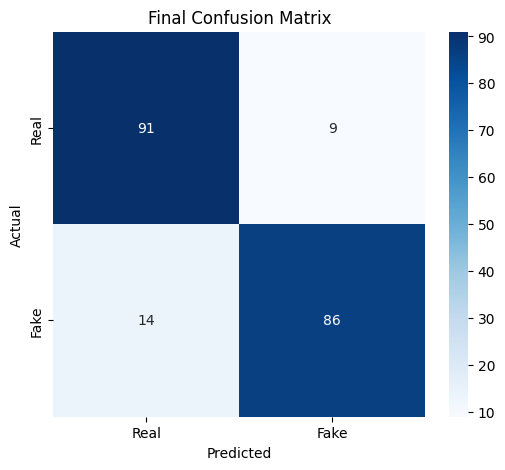


Detailed Report:
              precision    recall  f1-score   support

        Real       0.87      0.91      0.89       100
        Fake       0.91      0.86      0.88       100

    accuracy                           0.89       200
   macro avg       0.89      0.89      0.88       200
weighted avg       0.89      0.89      0.88       200



In [12]:
import os
import torch
import torch.nn as nn
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from glob import glob
from tqdm import tqdm
from torchvision import models
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score, 
    roc_auc_score, 
    confusion_matrix, 
    classification_report
)

# =========================
# CONFIG
# =========================
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# ✅ POINT TO THE TEST FOLDER (NOT TRAIN!)
TEST_DIR = r"C:\Users\ASUS\Desktop\project\preprocessed\celebdf\test"
MODEL_PATH = "best_celebdf_model.pt"  # Ensure this matches your saved model name

# =========================
# MODEL DEFINITION (Must Match Training)
# =========================
class CNN_BiLSTM(nn.Module):
    def __init__(self):
        super().__init__()
        backbone = models.efficientnet_b0(weights=None)
        self.cnn = backbone.features
        self.pool = nn.AdaptiveAvgPool2d(1)

        self.lstm = nn.LSTM(
            input_size=1280,
            hidden_size=256,
            num_layers=2,
            bidirectional=True,
            batch_first=True,
            dropout=0.3
        )

        self.classifier = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 2)
        )

    def forward(self, x):
        B, T, C, H, W = x.shape
        x = x.view(B*T, C, H, W)
        feats = self.cnn(x)
        feats = self.pool(feats).flatten(1)
        feats = feats.view(B, T, -1)
        lstm_out, _ = self.lstm(feats)
        return self.classifier(lstm_out[:, -1, :])

# =========================
# LOAD DATA & MODEL
# =========================
print(f"🚀 DEVICE: {DEVICE}")

# 1. Gather Test Files
real_files = sorted(glob(os.path.join(TEST_DIR, "real", "*.pt")))
fake_files = sorted(glob(os.path.join(TEST_DIR, "fake", "*.pt")))

if len(real_files) == 0 and len(fake_files) == 0:
    raise FileNotFoundError(f"❌ No files found in {TEST_DIR}. Check your path!")

files = real_files + fake_files
labels = [0]*len(real_files) + [1]*len(fake_files)

print("="*40)
print(f"📂 FINAL TEST SET")
print(f"Total Samples: {len(files)}")
print(f"Real Videos  : {len(real_files)}")
print(f"Fake Videos  : {len(fake_files)}")
print("="*40)

# 2. Load Model
model = CNN_BiLSTM().to(DEVICE)
try:
    model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
    model.eval()
    print(f"✅ Loaded weights from: {MODEL_PATH}")
except Exception as e:
    print(f"❌ Error loading model: {e}")
    exit()

# =========================
# INFERENCE LOOP
# =========================
y_true, y_pred, y_prob = [], [], []

print("\nrunning inference...")
with torch.no_grad():
    for file, label in tqdm(zip(files, labels), total=len(files)):
        try:
            # Load tensor (16, 3, 224, 224)
            x = torch.load(file).unsqueeze(0).to(DEVICE) 
            
            # Forward Pass
            out = model(x)
            prob = torch.softmax(out, 1)[0, 1].item() # Probability of being Fake
            pred = out.argmax(1).item()               # 0 or 1

            y_true.append(label)
            y_pred.append(pred)
            y_prob.append(prob)
        except Exception as e:
            print(f"⚠️ Corrupt file skipped: {file}")

# =========================
# FINAL METRICS REPORT
# =========================
acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec  = recall_score(y_true, y_pred)
f1   = f1_score(y_true, y_pred)
auc  = roc_auc_score(y_true, y_prob)
cm   = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()

# Specificity (True Negative Rate)
spec = tn / (tn + fp) if (tn + fp) > 0 else 0

print("\n" + "="*40)
print(f"🏆 FINAL RESULTS (Held-out Test Set)")
print("="*40)
print(f"Accuracy    : {acc:.4f}")
print(f"AUC Score   : {auc:.4f}")
print(f"F1 Score    : {f1:.4f}")
print("-" * 40)
print(f"Precision   : {prec:.4f}")
print(f"Recall      : {rec:.4f} (Sensitivity)")
print(f"Specificity : {spec:.4f} (True Negative Rate)")
print("="*40)
print("\nConfusion Matrix:")
print(f"TN: {tn:<4} | FP: {fp:<4} (Real flagged as Fake)")
print(f"FN: {fn:<4} | TP: {tp:<4} (Deepfakes detected)")
print("-" * 40)

# =========================
# VISUALIZATION
# =========================
# Plot Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Final Confusion Matrix')
plt.show()

# Classification Report
print("\nDetailed Report:")
print(classification_report(y_true, y_pred, target_names=["Real", "Fake"]))